In [1]:
# The pytorch version 2.4 is mostly tested for mamba_ssm Library so Downgrading default Pytorch version
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 2.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 56.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 28.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 48.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 MB 1.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.4

In [2]:
# Based on the GPU requriments of Kaggle and Pytorch version, downloading the appropriate Wheel files
!wget https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.2/causal_conv1d-1.5.2+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

!wget https://github.com/state-spaces/mamba/releases/download/v2.2.5/mamba_ssm-2.2.5+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

--2026-03-29 17:41:04--  https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.2/causal_conv1d-1.5.2+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/726718359/604a2e41-ef67-4125-bb18-e5c1bfafc2be?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-29T18%3A33%3A47Z&rscd=attachment%3B+filename%3Dcausal_conv1d-1.5.2%2Bcu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-29T17%3A33%3A41Z&ske=2026-03-29T18%3A33%3A47Z&sks=b&skv=2018-11-09&sig=CRqVjhMyOuLGj0YY1pN%2FLbA8ocvFzQ0gSI2AVb4IwmI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNl

In [3]:
# Installing the Wheel files
!pip install /kaggle/working/causal_conv1d-1.5.2+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
!pip install /kaggle/working/mamba_ssm-2.2.5+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

Processing ./causal_conv1d-1.5.2+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
Processing ./mamba_ssm-2.2.5+cu12torch2.4cxx11abiFALSE-cp311-cp311-linux_x86_64.whl


## Automated Feature Encoder
This class performs three critical functions:
* Normalization: It squashes raw hashed values into a $[0, 1]$ range.
* Projection: It maps 62 dimensions into 128 (expansion) and then to 32 (bottleneck).
* Stabilization: It uses LayerNorm to ensure that even if one feature is massive, it doesn't break the Mamba state.

In [4]:
import os
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from mamba_ssm import Mamba

In [5]:
class ObjectFeatureEngine:
    def __init__(self):
        # The 10 Objects from your Table
        self.object_schema = {
            "FLOW": {"p": ['src_ip', 'dest_ip', 'src_port', 'dest_port', 'l4protocol', 'direction'], "v": ['start_time', 'end_time', 'size']},
            "PROCESS": {"p": ['command_line', 'image_path', 'parent_image_path', 'user', 'sid'], "v": []},
            "FILES": {"p": ['image_path', 'info_class', 'file_path', 'new_path'], "v": ['size']},
            "MODULE": {"p": ['image_path', 'module_path'], "v": ['base_address']},
            "THREAD": {"p": ['image_path'], "v": ['stack_limit', 'stack_base', 'source_pid', 'source_tid', 'target_pid', 'target_tid', 'subprocess_tag']},
            "REGISTRY": {"p": ['image_path', 'key', 'type'], "v": ['data', 'value']},
            "TASK": {"p": ['image_path', 'task_process_uuid', 'path', 'task_name'], "v": ['task_pid']},
            "SHELL": {"p": ['image_path'], "v": ['payload', 'context_info']},
            "SERVICE": {"p": ['image_path', 'name', 'start_type', 'service_type'], "v": []},
            "USER_SESSION": {"p": ['privileges', 'logon_id', 'requesting_user'], "v": []}
        }
        self.obj_list = list(self.object_schema.keys())

    def extract_matrix(self, df):
        # 1. Immediate Hash-Mapping (Since data is already strings)
        expressions = []
        for obj in self.obj_list:
            # Permanent (Identity) hash sum
            p_cols = [c for c in self.object_schema[obj]["p"] if c in df.columns]
            p_expr = pl.lit(0.0).cast(pl.Float32)
            for c in p_cols:
                # Use fill_null("0") just in case, then hash
                p_expr += (pl.col(c).fill_null("0").hash().mod(1000).cast(pl.Float32) / 1000.0)
            
            # Volatile (Behavior) hash sum
            v_cols = [c for c in self.object_schema[obj]["v"] if c in df.columns]
            v_expr = pl.lit(0.0).cast(pl.Float32)
            for c in v_cols:
                v_expr += (pl.col(c).fill_null("0").hash().mod(1000).cast(pl.Float32) / 1000.0)
            
            expressions.extend([p_expr.alias(f"{obj}_p"), v_expr.alias(f"{obj}_v")])

        # 2. Temporal Logic (The only part that needs string->datetime conversion)
        ts = df["timestamp"].str.to_datetime(strict=False).dt.convert_time_zone("UTC").dt.replace_time_zone(None)
        td_log = (ts - ts.shift(1)).fill_null(pl.duration(milliseconds=0)).dt.total_milliseconds().cast(pl.Float32).log1p().alias("td_log")

        # 3. Final Stack
        processed = df.with_columns(expressions + [td_log])
        
        p_data = processed.select([f"{obj}_p" for obj in self.obj_list]).to_numpy()
        v_data = processed.select([f"{obj}_v" for obj in self.obj_list]).to_numpy()
        
        # Matrix shape: [Events, 10, 2]
        matrix = np.stack([p_data, v_data], axis=-1)
        time_feats = processed.select("td_log").to_numpy()
        labels = df.select(pl.col("is_malicious").cast(pl.Int32)).to_numpy()
        
        return matrix, time_feats, labels

In [6]:
class ObjectEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # Each object row [Perm, Vol] is embedded into 8 dimensions
        self.obj_embed = nn.Linear(2, 8)
        
        # 10 objects * 8 dims = 80 dims + 1 time dim = 81
        self.bottleneck = nn.Sequential(
            nn.Linear(81, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim),
            nn.LayerNorm(latent_dim)
        )

    def forward(self, obj_matrix, td_log):
        """
        obj_matrix: [Batch, Seq, 10, 2]
        td_log: [Batch, Seq, 1]
        """
        # Embed object rows: [B, S, 10, 8]
        z_obj = self.obj_embed(obj_matrix)
        
        # Flatten: [B, S, 80]
        z_flat = z_obj.view(z_obj.size(0), z_obj.size(1), -1)
        
        # Combine with time: [B, S, 81]
        combined = torch.cat([z_flat, td_log], dim=-1)
        
        return self.bottleneck(combined)

In [7]:
class StateVault:
    def __init__(self, vault_path="/kaggle/working/mamba_states"):
        self.vault_path = vault_path
        os.makedirs(self.vault_path, exist_ok=True)
        print(f"--- StateVault initialized at {vault_path} ---")

    def _get_path(self, host_id):
        # We store states as .pt files named after the host
        return os.path.join(self.vault_path, f"{host_id}_hidden.pt")

    def save_host_state(self, host_id, state_tuple):
        """
        Saves the Mamba RNN state (cache) to disk.
        state_tuple: (conv_state, ssm_state)
        """
        torch.save(state_tuple, self._get_path(host_id))

    def load_host_state(self, host_id, device="cuda"):
        """
        Loads the state. Returns None if it's the first time seeing this host.
        """
        path = self._get_path(host_id)
        if os.path.exists(path):
            state = torch.load(path, map_location=device)
            return state
        return None

    def exists(self, host_id):
        return os.path.exists(self._get_path(host_id))

In [37]:
class InfiniteHorizonMamba(nn.Module):
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        # Stream 1: Action/Volatile Embedding (Processes the "What")
        # 10 objects * 1 dim (Volatile) + 1 time dim = 11
        self.action_fusion = nn.Sequential(
            nn.Linear(11, d_model),
            nn.SiLU(),
            nn.LayerNorm(d_model)
        )
        
        # Stream 2: Identity/Permanent Embedding (Processes the "Who")
        # 10 objects * 1 dim (Permanent) = 10
        self.identity_anchor = nn.Linear(10, d_model)
        
        # The Sequential Core
        self.mamba = Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2)
        
        # The Gating Mechanism
        self.gate = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Sigmoid()
        )
        
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, obj_matrix, td_log, state=None):
        """
        obj_matrix: [Batch, Seq, 10, 2] -> 0 is Perm, 1 is Vol
        td_log: [Batch, Seq, 1]
        """
        # --- 1. Disentangle the Streams ---
        # Identity (P): [Batch, Seq, 10]
        perm = obj_matrix[:, :, :, 0] 
        # Action (V): [Batch, Seq, 10]
        vol = obj_matrix[:, :, :, 1]  
        
        # --- 2. Process Action Stream through Mamba ---
        action_input = torch.cat([vol, td_log], dim=-1) # [B, S, 11]
        x_action = self.action_fusion(action_input)
        x_action = self.mamba(x_action) 
        
        # --- 3. Process Identity Stream (The Anchor) ---
        x_id = self.identity_anchor(perm)
        
        # --- 4. Gated Residual Fusion ---
        # Formula: H = Gate(ID) * Action + (1 - Gate(ID)) * ID
        g = self.gate(x_id)
        combined = (g * x_action) + ((1 - g) * x_id)
        
        return self.classifier(combined), None

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
class PIDSEvaluator:
    def __init__(self, model, engine, window_size=5000):
        self.model = model
        self.engine = engine
        self.window_size = window_size
        self.model.eval()

    def evaluate_test_hosts(self, test_hosts, threshold = 0.4):
        all_y_true = []
        all_y_pred = []
        
        print(f"📊 Evaluating {len(test_hosts)} Hosts with Windowing...")
        
        with torch.no_grad():
            for host_id in test_hosts:
                for day in [23, 24, 25]:
                    search_pattern = f"/kaggle/working/sep{day}/*{host_id}*.parquet"
                    files = glob.glob(search_pattern)
                    if not files: continue
                    
                    print(f"   🔎 Processing Day {day} for Host {host_id}...")
                    df = pl.read_parquet(files[0])
                    matrix, td_log, y_true = self.engine.extract_matrix(df)
                    
                    num_events = matrix.shape[0]
                    day_preds = []

                    # Process in windows to prevent OOM
                    for i in range(0, num_events, self.window_size):
                        end_idx = i + self.window_size
                        
                        m_win = torch.from_numpy(matrix[i:end_idx]).float().unsqueeze(0).to("cuda")
                        t_win = torch.from_numpy(td_log[i:end_idx]).float().unsqueeze(0).to("cuda")
                        
                        logits = self.model(m_win, t_win)
                        if isinstance(logits, tuple): logits = logits[0]
                        
                        probs = torch.sigmoid(logits)
                        preds = (probs > threshold).int().cpu().numpy().flatten()
                        day_preds.extend(preds)
                    
                    all_y_true.extend(y_true.flatten())
                    all_y_pred.extend(day_preds)
                    
                    # Clean up VRAM after each day
                    torch.cuda.empty_cache()

        if len(all_y_true) == 0:
            print("❌ No labels found. Evaluation failed.")
            return None

        # Calculate Metrics
        p, r, f1, _ = precision_recall_fscore_support(all_y_true, all_y_pred, average='binary', zero_division=0)
        cm = confusion_matrix(all_y_true, all_y_pred)
        
        print(f"\n📈 Final Research Metrics:")
        print(f"Precision: {p:.4f}")
        print(f"Recall:    {r:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        
        return cm

    def plot_confusion_matrix(self, cm):
        if cm is None: return
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('PIDS Detection Confusion Matrix')
        plt.show()

In [16]:
import glob
from huggingface_hub import snapshot_download

class OpTCDataIngest:
    def __init__(self, repo_id, local_dir="/kaggle/working"):
        self.repo_id = repo_id
        self.local_dir = local_dir

    def download_host_history(self, host_id):
        """Downloads all 10 days for a specific host."""
        for day in range(16, 26):
            snapshot_download(
                repo_id=self.repo_id,
                repo_type="dataset",
                local_dir=self.local_dir,
                allow_patterns=f"sep{day}/*{host_id}*.parquet",
                max_workers=4
            )

## Focus on the rare ones(is_malicious = 1)
As we know the malicious events are rare.

In [33]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss) # Prevents gradient vanishing
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return F_loss.mean()

In [38]:
class ResearchTrainer:
    def __init__(self, model, vault, repo_id, window_size=2000):
        self.model = model.to("cuda")
        self.vault = vault
        self.window_size = window_size
        self.ingest = OpTCDataIngest(repo_id)
        self.engine = ObjectFeatureEngine()
        # self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=5e-5)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=3e-5, weight_decay=0.01)
        # self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1000.0]).to("cuda"))
        # self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2000.0]).to("cuda"))
        self.criterion = FocalLoss(alpha=0.25, gamma=2.0).to("cuda")

    def train_host_lifecycle(self, host_id):
        print(f"\n🚀 Processing Host: {host_id}")
        self.ingest.download_host_history(host_id)
        
        for day in range(16, 26):
            path = f"/kaggle/working/sep{day}/*{host_id}*.parquet"
            files = glob.glob(path)
            if not files: continue
            
            try:
                df = pl.read_parquet(files[0])
                matrix, td_log, labels = self.engine.extract_matrix(df)
                
                # WINDOWED PROCESSING: Prevents OOM
                num_events = matrix.shape[0]
                for i in range(0, num_events, self.window_size):
                    end_idx = i + self.window_size
                    
                    # Slice the window
                    m_win = torch.from_numpy(matrix[i:end_idx]).float().unsqueeze(0).to("cuda")
                    t_win = torch.from_numpy(td_log[i:end_idx]).float().unsqueeze(0).to("cuda")
                    y_win = torch.from_numpy(labels[i:end_idx]).float().unsqueeze(0).to("cuda")

                    self.model.train()
                    self.optimizer.zero_grad()
                    
                    logits, _ = self.model(m_win, t_win)
                    loss = self.criterion(logits, y_win)
                    
                    if not torch.isnan(loss):
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                        self.optimizer.step()
                
                print(f"   ✅ Day {day} complete. (Events: {num_events})")
                
                # CRITICAL: Clear cache to prevent OOM creep
                torch.cuda.empty_cache()

            except Exception as e:
                print(f"   ❌ Error Day {day}: {e}")
                torch.cuda.empty_cache()

 
# # --- EXECUTION ---
# # Initialize the full system
# vault = StateVault()
# pids_model = InfiniteHorizonMamba()
# trainer = ResearchTrainer(pids_model, vault, "equalNull/hosts100-labelled-optc")

# # Run for your host list
# target_hosts = ["0104", "0618", "0256"] 
# for host in target_hosts:
#     trainer.train_host_lifecycle(host)

In [39]:
# 1. Initialize the Core Engine (Do this ONCE)
global_engine = ObjectFeatureEngine()

# 2. Initialize the Vault and Model
vault = StateVault()
pids_model = InfiniteHorizonMamba().to("cuda")

# 3. Initialize the Trainer using the global_engine
trainer = ResearchTrainer(pids_model, vault, "equalNull/hosts100-labelled-optc")
trainer.engine = global_engine  # Explicitly link them

# 4. RUN TRAINING (Pick one host to test)
trainer.train_host_lifecycle("0618")

# --- FINAL REPORTING ---
# 5. Save the Model
torch.save(pids_model.state_dict(), "infinite_horizon_mamba_final.pt")
print("💾 Model saved: infinite_horizon_mamba_final.pt")

--- StateVault initialized at /kaggle/working/mamba_states ---

🚀 Processing Host: 0618


Fetching 0 files: 0it [00:00, ?it/s]

Fetching 0 files: 0it [00:00, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ Day 18 complete. (Events: 1046901)
   ✅ Day 19 complete. (Events: 5050067)
   ✅ Day 20 complete. (Events: 3810425)
   ✅ Day 21 complete. (Events: 4819448)
   ✅ Day 22 complete. (Events: 4900532)
   ✅ Day 23 complete. (Events: 4594184)
   ✅ Day 24 complete. (Events: 4071826)
   ✅ Day 25 complete. (Events: 2407405)
💾 Model saved: infinite_horizon_mamba_final.pt


📊 Evaluating 1 Hosts with Windowing...
   🔎 Processing Day 23 for Host 0618...
   🔎 Processing Day 24 for Host 0618...
   🔎 Processing Day 25 for Host 0618...

📈 Final Research Metrics:
Precision: 0.0177
Recall:    0.4518
F1-Score:  0.0340


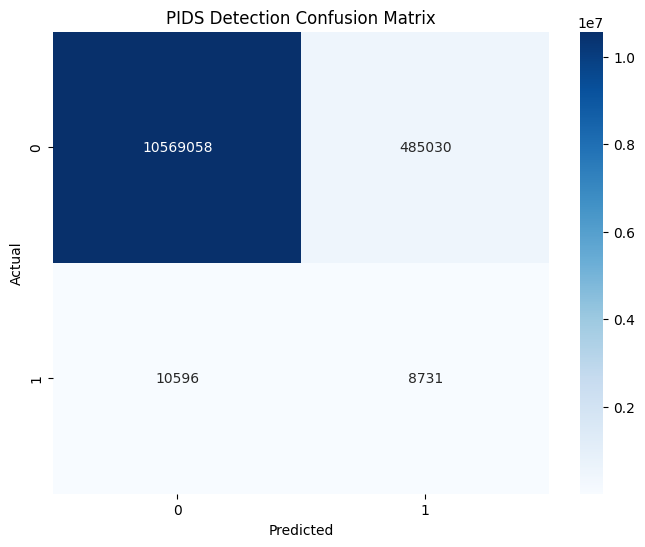

In [42]:
# 6. Run Evaluation using the SAME engine
evaluator = PIDSEvaluator(pids_model, global_engine)

test_hosts = ["0618"] # Testing on the same host for now to verify it works
try:
    cm = evaluator.evaluate_test_hosts(test_hosts)
    evaluator.plot_confusion_matrix(cm)
except Exception as e:
    print(f"⚠️ Evaluation Error: {e}")

In [49]:
# 6. Run Evaluation using the SAME engine
evaluator = PIDSEvaluator(pids_model, global_engine)

test_hosts = ["0618"] # Testing on the same host for now to verify it works
try:
    for t in np.arange(0.1, 0.8, 0.1):
        cm = evaluator.evaluate_test_hosts(test_hosts, threshold = t)
except Exception as e:
    print(f"⚠️ Evaluation Error: {e}")

📊 Evaluating 1 Hosts with Windowing...
   🔎 Processing Day 23 for Host 0618...
   🔎 Processing Day 24 for Host 0618...
   🔎 Processing Day 25 for Host 0618...

📈 Final Research Metrics:
Precision: 0.0025
Recall:    0.6579
F1-Score:  0.0050
📊 Evaluating 1 Hosts with Windowing...
   🔎 Processing Day 23 for Host 0618...
   🔎 Processing Day 24 for Host 0618...
   🔎 Processing Day 25 for Host 0618...

📈 Final Research Metrics:
Precision: 0.0057
Recall:    0.5324
F1-Score:  0.0112
📊 Evaluating 1 Hosts with Windowing...
   🔎 Processing Day 23 for Host 0618...
   🔎 Processing Day 24 for Host 0618...
   🔎 Processing Day 25 for Host 0618...

📈 Final Research Metrics:
Precision: 0.0177
Recall:    0.4518
F1-Score:  0.0340
📊 Evaluating 1 Hosts with Windowing...
   🔎 Processing Day 23 for Host 0618...
   🔎 Processing Day 24 for Host 0618...
   🔎 Processing Day 25 for Host 0618...

📈 Final Research Metrics:
Precision: 0.0474
Recall:    0.3312
F1-Score:  0.0829
📊 Evaluating 1 Hosts with Windowing...
 